# gprMax input-file generator
In this notebook:
- Generates input-files that can be used for gprMax forward simulations
- You can control the model geometry (width, depth, fracture depth, material properties)
- You can control auxiliary variables (source position, number of receivers, receiver locations)
- Export the input files to run in the terminal
- Visualise the geometry before creating an input-file

In [55]:
import numpy as np
from fractions import Fraction

# ── Simulation frequency ──────────────────────────────────────────────────────
f_central = 1.5e9          # [Hz]  centre frequency
c         = 3e8            # [m/s] speed of light in vacuum

# ── Material permittivities & conductivities ──────────────────────────────────
eps_ice,   sigma_ice   = 3.15, 1e-6
eps_air,   sigma_air   = 1.0,  0.0
eps_water, sigma_water = 80.0, 0.01

# ── Block geometry ────────────────────────────────────────────────────────────
block_width_fraction = Fraction(10, 1)    # block width as fraction of lambda_ice
fracture_aperture    = None   # [m]  None -> auto-set to lambda_min / 5

# ── Domain geometry ───────────────────────────────────────────────────────────
domain_width   = 4.0   # [m]
air_thickness  = 0.1   # [m] air layer above ice surface (antenna coupling)
fracture_depth = 0.6   # [m] depth from ice surface to top of fracture
depth_below    = 0.1   # [m] ice below the fracture

# ── Source & receivers ────────────────────────────────────────────────────────
tx_x      = domain_width / 2   # [m] transmitter x-position (domain centre)
rx_count  = 100
rx_spread = 2.0                # [m] total receiver spread (centred on tx)

# ── Timelapse shift ───────────────────────────────────────────────────────────
shift_fraction = 6   # Model B blocks shifted by (shift_fraction * lambda_ice)

# ── Snapshots ──────────────────────────────────────────────────────────────────────────────
enable_snapshots = True    # False -> no #snapshot lines (faster runs, no .vti files)
snap_dl_factor   = 10      # Snapshot resolution = snap_dl_factor * dx
                           # (10 -> ~10x coarser than grid; keeps .vti files small)
snap_interval    = 0.5e-9  # [s] time between consecutive snapshots

# ── Derived wavelengths & required grid spacing ───────────────────────────────
c_ice        = c / np.sqrt(eps_ice)
c_water      = c / np.sqrt(eps_water)
lambda_ice   = c_ice   / f_central
lambda_water = c_water / f_central
lambda_min   = min(lambda_ice, lambda_water)

dx = lambda_min / 30   # >=30 cells per shortest wavelength

print(f"lambda_ice   = {lambda_ice*1e2:.3f} cm")
print(f"lambda_water = {lambda_water*1e3:.3f} mm")
print(f"dx           = {dx*1e3:.4f} mm")

lambda_ice   = 11.269 cm
lambda_water = 22.361 mm
dx           = 0.7454 mm


In [56]:
# ── Fracture aperture ─────────────────────────────────────────────────────────
if fracture_aperture is None:
    fracture_aperture = lambda_min / 5

# ── Block sizing & timelapse shift ────────────────────────────────────────────
block_width      = block_width_fraction * lambda_ice
time_lapse_shift = shift_fraction * lambda_ice

# ── Domain snapped to grid ────────────────────────────────────────────────────
domain_height = air_thickness + fracture_depth + fracture_aperture + depth_below
domain_width  = np.ceil(domain_width  / dx) * dx
domain_height = np.ceil(domain_height / dx) * dx

# ── Time window (5 periods + 3x two-way travel to fracture) ──────────────────
TW = (5 / f_central) + 3 * (fracture_depth + fracture_aperture) / c_ice

# ── gprMax y-coordinates (origin at bottom-left corner) ──────────────────────
y_surface  = domain_height - air_thickness
y_frac_top = domain_height - (air_thickness + fracture_depth)
y_frac_bot = y_frac_top - fracture_aperture
y_frac_min = min(y_frac_top, y_frac_bot)
y_frac_max = max(y_frac_top, y_frac_bot)

# ── Block count — must be even for symmetric Air/Water alternation ─────────────
n_blocks = int(np.round(domain_width / block_width))
if n_blocks < 1:       n_blocks = 1
if n_blocks % 2 != 0:  n_blocks += 1
block_width_actual = domain_width / n_blocks

# ── Receiver positions ────────────────────────────────────────────────────────
rx_min_x   = tx_x - rx_spread / 2
rx_spacing = rx_spread / max(1, rx_count - 1)

# ── Human-readable block-width label ─────────────────────────────────────────
fr = Fraction(block_width_actual / lambda_ice).limit_denominator(32)
block_label = f"{fr.numerator}/{fr.denominator} \u03bb_ice"

print(f"Domain:            {domain_width:.4f} m \u00d7 {domain_height:.4f} m")
print(f"Grid cells:        {domain_width/dx:.0f} \u00d7 {domain_height/dx:.0f}")
print(f"Fracture aperture: {fracture_aperture*1e3:.3f} mm")
print(f"Block width:       {block_width_actual*1e3:.3f} mm  ({block_label})")
print(f"N blocks:          {n_blocks}")
print(f"Timelapse shift:   {time_lapse_shift*1e3:.3f} mm  ({shift_fraction} \u03bb_ice)")
print(f"Time window:       {TW*1e9:.3f} ns")

Domain:            4.0003 m × 0.8050 m
Grid cells:        5367 × 1080
Fracture aperture: 4.472 mm
Block width:       1000.081 mm  (71/8 λ_ice)
N blocks:          4
Timelapse shift:   676.123 mm  (6 λ_ice)
Time window:       14.062 ns


In [57]:
import os

output_dir  = os.path.dirname(os.path.abspath("__file__"))
file_prefix = ""   # e.g. "fracture_10cm" -> fracture_10cm_baseline.in / fracture_10cm_timelapse.in
                   # leave empty "" for default names: baseline.in / timelapse.in


def _fname(prefix, suffix):
    return f"{prefix}_{suffix}.in" if prefix else f"{suffix}.in"


def build_in_file(block_shift: float, title: str, snap_name: str = "snap") -> str:
    lines = [
        f"#title: {title}",
        f"#domain: {domain_width} {domain_height} {dx}",
        f"#dx_dy_dz: {dx} {dx} {dx}",
        f"#time_window: {TW}",
        f"#material: {eps_ice} {sigma_ice} 1 0 ice",
        f"#material: {eps_air} {sigma_air} 1 0 fracture_air",
        f"#material: {eps_water} {sigma_water} 1 0 fracture_water",
        f"#waveform: ricker 1 {f_central} my_ricker",
        f"#hertzian_dipole: z {tx_x} {y_surface} 0 my_ricker",
    ]
    for i in range(rx_count):
        lines.append(f"#rx: {rx_min_x + i * rx_spacing} {y_surface} 0")
    lines.append(f"#box: 0 {y_surface} 0 {domain_width} {domain_height} {dx} free_space")
    lines.append(f"#box: 0 0 0 {domain_width} {y_surface} {dx} ice")
    for i in range(n_blocks):
        x0 = i * block_width_actual + block_shift
        x1 = x0 + block_width_actual
        x0 = min(max(0.0, x0), domain_width)
        x1 = min(max(0.0, x1), domain_width)
        if x0 >= x1:
            continue
        mat = "fracture_air" if i % 2 == 0 else "fracture_water"
        lines.append(f"#box: {x0} {y_frac_min} 0 {x1} {y_frac_max} {dx} {mat}")
    if enable_snapshots:
        snap_dl = snap_dl_factor * dx
        n_snaps = max(1, int(TW / snap_interval))
        for i in range(1, n_snaps + 1):
            t = i * snap_interval
            lines.append(
                f"#snapshot: 0 0 0 {domain_width} {domain_height} {dx}"
                f" {snap_dl} {snap_dl} {dx} {t} {snap_name}_{i}"
            )
    return "\n".join(lines)


tag = f" [{file_prefix}]" if file_prefix else ""
baseline_path  = os.path.join(output_dir, _fname(file_prefix, "baseline"))
timelapse_path = os.path.join(output_dir, _fname(file_prefix, "timelapse"))

with open(baseline_path,  "w") as f:
    stem_b = _fname(file_prefix, "baseline")[:-3]
    f.write(build_in_file(0.0,              f"Model A \u2014 Baseline{tag}",  snap_name=stem_b))
with open(timelapse_path, "w") as f:
    stem_t = _fname(file_prefix, "timelapse")[:-3]
    f.write(build_in_file(time_lapse_shift, f"Model B \u2014 Timelapse{tag}", snap_name=stem_t))

print(f"Wrote: {baseline_path}")
print(f"Wrote: {timelapse_path}")

Wrote: c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\baseline.in
Wrote: c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse.in


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7832\3622621824.py:64: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7832\3622621824.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


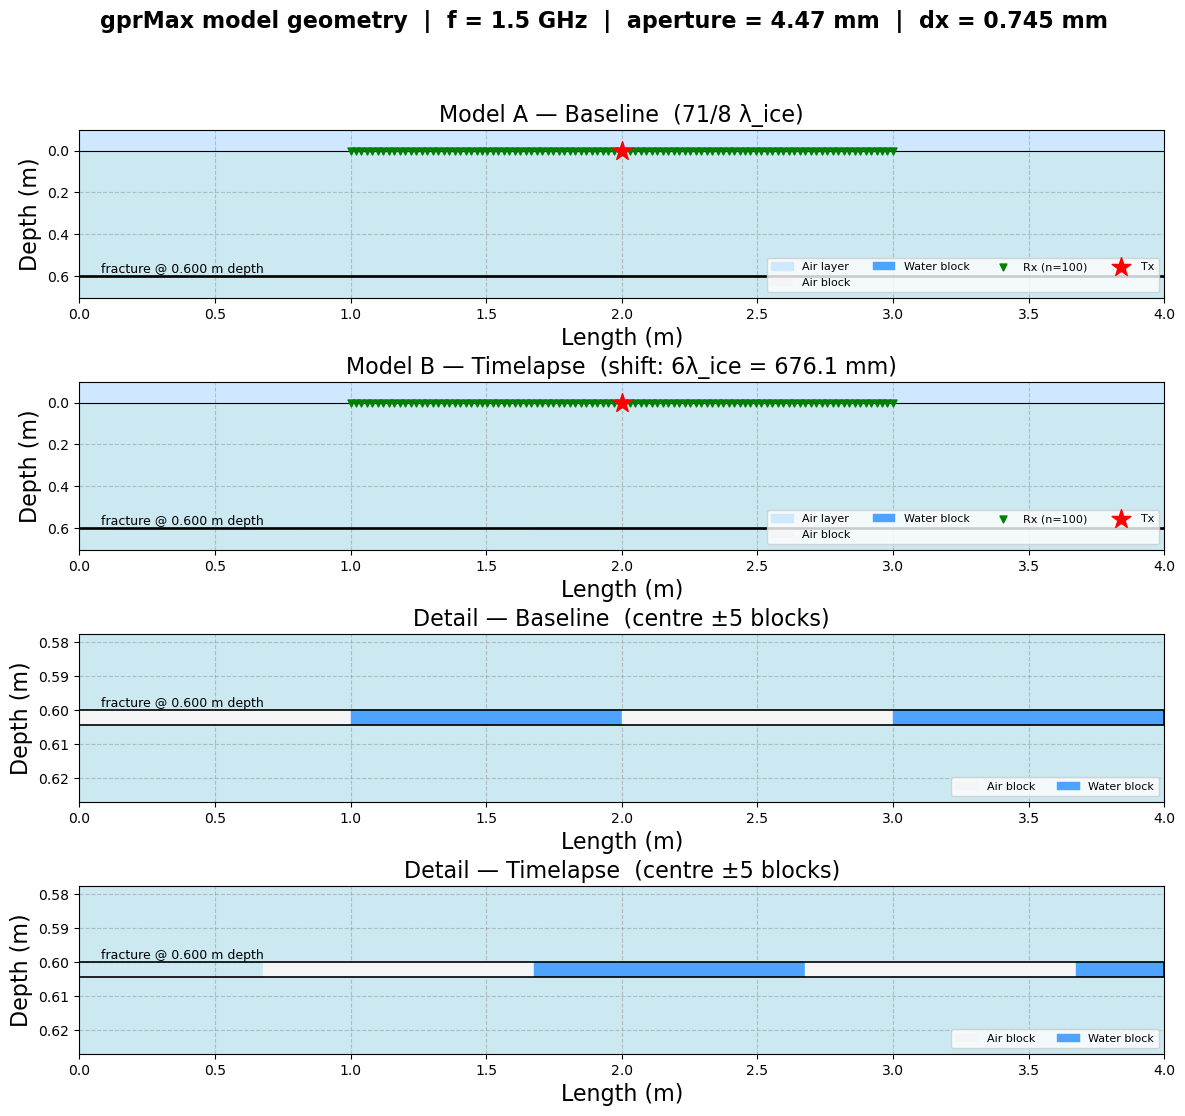

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# ── Style constants (matching notebook_experiment_9) ─────────────────────────
ICE_COLOR      = "#cce8f0"
AIR_COLOR      = "#cfe8ff"   # exp9 exact
FRAC_AIR_COLOR = "#f5f5f5"
FRAC_WAT_COLOR = "#4da3ff"   # exp9 exact
LABEL_SIZE     = 16
TITLE_SIZE     = 16

# ── Depth-coordinate constants ────────────────────────────────────────────────
# depth = 0 at ice surface, increases downward (same convention as exp9)
depth_total = fracture_depth + fracture_aperture + depth_below

# ── Figure: 4 rows (full-A, full-B, detail-A, detail-B) ──────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.5)
ax_A     = fig.add_subplot(gs[0])
ax_B     = fig.add_subplot(gs[1], sharex=ax_A)
ax_A_det = fig.add_subplot(gs[2])
ax_B_det = fig.add_subplot(gs[3], sharex=ax_A_det)


def draw_model(ax, block_shift, title, zoom=None):
    """
    Plot model in depth coordinates (0 = ice surface, increases downward).
    zoom=None       -> full domain with antenna markers.
    zoom=(xc, hw)   -> fracture detail: x in [xc-hw, xc+hw], y tightly around fracture.
    Every fracture #box is drawn individually so the plot mirrors the .in file exactly.
    """
    if zoom is None:
        x_lo, x_hi   = 0.0, domain_width
        y_bot, y_top  = depth_total, -air_thickness   # set_ylim(bot, top) with bot>top -> inverted
        show_antennas = True
    else:
        x_c, hw = zoom
        x_lo, x_hi   = max(0.0, x_c - hw), min(domain_width, x_c + hw)
        margin        = max(5 * fracture_aperture, 0.01)
        y_bot         = fracture_depth + fracture_aperture + margin
        y_top         = fracture_depth - margin
        show_antennas = False

    ax.set_facecolor(ICE_COLOR)

    # Air layer (depth from -air_thickness to 0) — full view only
    if zoom is None:
        ax.add_patch(patches.Rectangle(
            (x_lo, -air_thickness), x_hi - x_lo, air_thickness,
            color=AIR_COLOR, zorder=1, label="Air layer"))
        ax.axhline(0, color="black", linewidth=0.8, zorder=4)

    # Fracture blocks — one Rectangle per #box in the .in file
    for i in range(n_blocks):
        bx0 = i * block_width_actual + block_shift
        bx1 = bx0 + block_width_actual
        bx0 = min(max(0.0, bx0), domain_width)
        bx1 = min(max(0.0, bx1), domain_width)
        if bx0 >= bx1:
            continue
        color = FRAC_AIR_COLOR if i % 2 == 0 else FRAC_WAT_COLOR
        lbl   = "Air block" if i == 0 else ("Water block" if i == 1 else None)
        ax.add_patch(patches.Rectangle(
            (bx0, fracture_depth), bx1 - bx0, fracture_aperture,
            color=color, zorder=2, label=lbl, linewidth=0.3, edgecolor="grey"))

    # Fracture zone outline
    ax.add_patch(patches.Rectangle(
        (x_lo, fracture_depth), x_hi - x_lo, fracture_aperture,
        fill=False, edgecolor="black", linewidth=1.2, zorder=3))

    # Antenna markers — full view only
    if show_antennas:
        rx_xs = [rx_min_x + i * rx_spacing for i in range(rx_count)]
        ax.scatter(rx_xs, [0] * rx_count,
                   marker="v", s=25, color="green", zorder=5, label=f"Rx (n={rx_count})")
        ax.scatter([tx_x], [0], marker="*", s=200, color="red", zorder=5, label="Tx")

    # Axis formatting (exp9 style: set_ylim with bot>top, no invert_yaxis)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_bot, y_top)
    ax.set_xlabel("Length (m)", fontsize=LABEL_SIZE)
    ax.set_ylabel("Depth (m)",  fontsize=LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.grid(True, linestyle="--", alpha=0.4, color="grey")
    ax.legend(loc="lower right", fontsize=8, ncol=4)
    ax.annotate(
        f"fracture @ {fracture_depth:.3f} m depth",
        xy=(x_lo + 0.02 * (x_hi - x_lo), fracture_depth),
        fontsize=9, color="black", va="bottom")


# ── Full-domain views ─────────────────────────────────────────────────────────
draw_model(ax_A, 0.0,
           f"Model A \u2014 Baseline  ({block_label})")
draw_model(ax_B, time_lapse_shift,
           f"Model B \u2014 Timelapse  "
           f"(shift: {shift_fraction}\u03bb_ice = {time_lapse_shift*1e3:.1f} mm)")

# ── Fracture detail views (+/-5 blocks around transmitter) ────────────────────
zoom_hw = 5 * block_width_actual
draw_model(ax_A_det, 0.0,
           "Detail \u2014 Baseline  (centre \u00b15 blocks)",
           zoom=(tx_x, zoom_hw))
draw_model(ax_B_det, time_lapse_shift,
           "Detail \u2014 Timelapse  (centre \u00b15 blocks)",
           zoom=(tx_x, zoom_hw))

fig.suptitle(
    f"gprMax model geometry  |  f = {f_central/1e9:.1f} GHz  |  "
    f"aperture = {fracture_aperture*1e3:.2f} mm  |  dx = {dx*1e3:.3f} mm",
    fontsize=TITLE_SIZE, weight="bold")
plt.tight_layout()
plt.show()